In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("retail_sales.csv")
df

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount
0,2023-04-13,Bag,Electronics,29838,4,Hyderabad,119352
1,2023-12-15,Shoes,Clothing,30419,1,Mumbai,30419
2,2023-09-28,Jacket,Accessories,8633,2,Kolkata,17266
3,2023-04-17,Tshirt,Accessories,5710,4,Hyderabad,22840
4,2023-03-13,Headphones,Clothing,18139,3,Pune,54417
...,...,...,...,...,...,...,...
995,2023-02-07,Mobile,Footwear,40686,4,Pune,162744
996,2023-10-20,Shoes,Footwear,20631,4,Bangalore,82524
997,2023-05-19,Shoes,Fragrance,18360,1,Pune,18360
998,2023-12-22,Shoes,Fragrance,1496,3,Mumbai,4488


In [3]:
df.head()

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount
0,2023-04-13,Bag,Electronics,29838,4,Hyderabad,119352
1,2023-12-15,Shoes,Clothing,30419,1,Mumbai,30419
2,2023-09-28,Jacket,Accessories,8633,2,Kolkata,17266
3,2023-04-17,Tshirt,Accessories,5710,4,Hyderabad,22840
4,2023-03-13,Headphones,Clothing,18139,3,Pune,54417


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Date          1000 non-null   object
 1   Product       1000 non-null   object
 2   Category      1000 non-null   object
 3   Unit_Price    1000 non-null   int64 
 4   Quantity      1000 non-null   int64 
 5   Store         1000 non-null   object
 6   Total_Amount  1000 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 54.8+ KB


In [5]:
df.isnull().sum()

Date            0
Product         0
Category        0
Unit_Price      0
Quantity        0
Store           0
Total_Amount    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Date"]=pd.to_datetime(df["Date"])
df["Months"]=df["Date"].dt.to_period("M")
df["Year"]=df["Date"].dt.year

In [8]:
df=df.sort_values("Months")
df

,Date,Product,Category,Unit_Price,Quantity,Store,Total_Amount,Months,Year
991,2023-01-01,Perfume,Accessories,27536,1,Mumbai,27536,2023-01,2023
987,2023-01-20,Laptop,Footwear,43763,3,Hyderabad,131289,2023-01,2023
50,2023-01-14,Laptop,Electronics,18040,1,Pune,18040,2023-01,2023
968,2023-01-04,Mobile,Electronics,55688,1,Chennai,55688,2023-01,2023
894,2023-01-07,Tshirt,Clothing,44554,3,Bangalore,133662,2023-01,2023
...,...,...,...,...,...,...,...,...,...
37,2023-12-30,Bag,Fragrance,59456,2,Kolkata,118912,2023-12,2023
28,2023-12-11,Tshirt,Fragrance,5782,1,Chennai,5782,2023-12,2023
969,2023-12-01,Mobile,Footwear,41345,4,Kolkata,165380,2023-12,2023
998,2023-12-22,Shoes,Fragrance,1496,3,Mumbai,4488,2023-12,2023


In [9]:
total_revenue=df["Total_Amount"].sum()
total_quantity=df["Quantity"].sum()
average=df["Total_Amount"].mean()
total_orders=len(df)

total_revenue,total_quantity,average,total_orders

(np.int64(72040453), np.int64(2445), np.float64(72040.453), 1000)

In [10]:
rev_month=df.groupby("Months")["Total_Amount"].sum()
rev_month

Months
2023-01    5614433
2023-02    5659730
2023-03    4518016
2023-04    7272475
2023-05    6640169
2023-06    6990207
2023-07    5285499
2023-08    7088970
2023-09    5646961
2023-10    4887810
2023-11    5707758
2023-12    6728425
Freq: M, Name: Total_Amount, dtype: int64

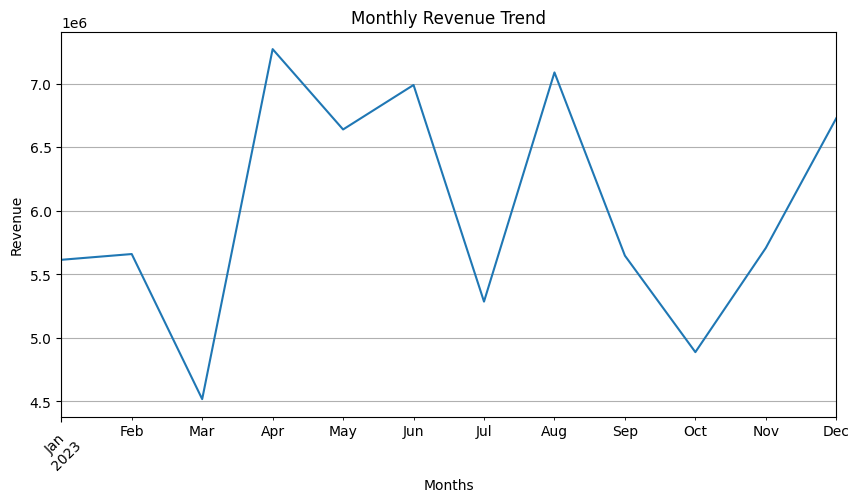

In [11]:
plt.figure(figsize=(10,5))
rev_month.plot(kind="line")
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [12]:
top_product=df.groupby("Product")["Total_Amount"].sum().sort_values(ascending=False)
print(top_product)

Product
Headphones    8305086
Jacket        8216379
Shoes         7519192
Tshirt        7191088
Mobile        7159371
Bag           7087134
Perfume       6747443
Watch         6621005
Jeans         6597908
Laptop        6595847
Name: Total_Amount, dtype: int64


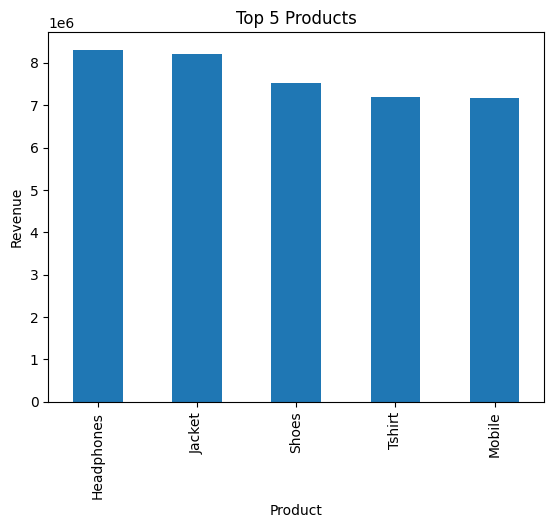

In [13]:
top_product.head(5).plot(kind="bar")
plt.title("Top 5 Products")
plt.ylabel("Revenue")
plt.show()

In [14]:
rev_category=df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)
rev_category

Category
Electronics    16383286
Footwear       14416250
Fragrance      14333294
Clothing       13735377
Accessories    13172246
Name: Total_Amount, dtype: int64

Text(0.5, 1.0, 'Category Contribution')

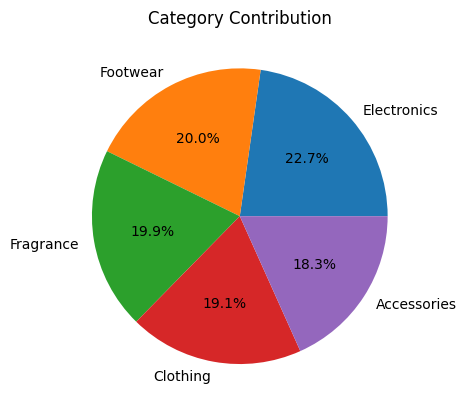

In [15]:
rev_category.plot(kind="pie",autopct="%1.1f%%",)
plt.ylabel("")
plt.title("Category Contribution")

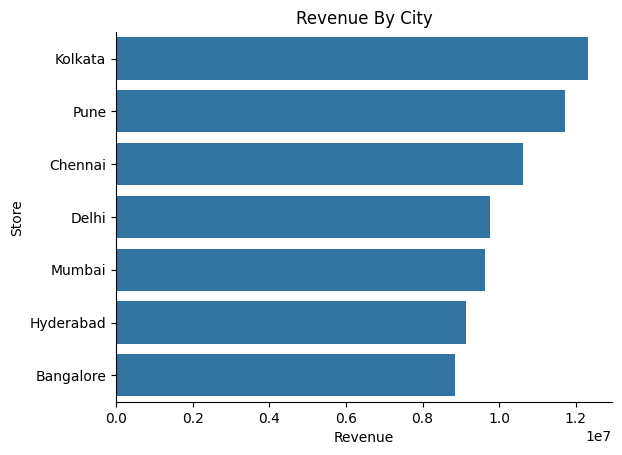

In [16]:
rev_by_city=df.groupby("Store")["Total_Amount"].sum().sort_values(ascending=False)
sns.barplot(x=rev_by_city.values,y=rev_by_city.index)
plt.title("Revenue By City")
plt.xlabel("Revenue")
sns.despine()

C:\Users\Admin\AppData\Local\Temp\ipykernel_2072\1708945470.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="Category",palette="Set1")


Text(0.5, 1.0, 'Total Number of Category')

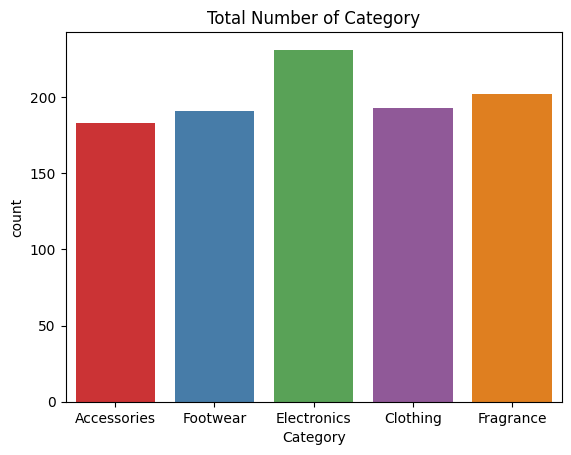

In [18]:
sns.countplot(data=df,x="Category",palette="Set1")
plt.title("Total Number of Category")

In [21]:
print("Total Revenue:",total_revenue)
print("Avg Order Value:",average)
print("Top Product:",top_product.index[0])
print("Top City:",rev_by_city.index[0])

Total Revenue: 72040453
Avg Order Value: 72040.453
Top Product: Headphones
Top City: Kolkata
